# More CRN examples

This notebook applies the same tools introduced in the
[README](https://github.com/UC-Davis-molecular-computing/batss#readme) — `species`, `Simulation`, `run`,
and `sim.history` — to four more chemical reaction networks:

* [Dimerization](#dimerization)
* [Rössler-Willamowski](#rössler-willamowski)
* [Oregonator](#oregonator)
* [Brusselator](#brusselator)

The README uses Lotka-Volterra as its running example, so start there if you have not already; everything
below assumes it.

Each example follows the same shape: declare the species, write the reactions, build a `Simulation`, run it,
and plot `sim.history`. All of them are simulated with $n = 10^5$.

In [1]:
from batss import species, Simulation

n = 10 ** 5

## Dimerization

Two monomers $M$ reversibly bind into a dimer $D$:

$$2M \underset{1}{\overset{1}{\rightleftharpoons}} D.$$

This is the simplest interesting CRN here. It is *reversible*, so unlike the Lotka-Volterra oscillator it
settles into a genuine equilibrium: the counts stop changing on average, and thereafter just fluctuate
around the equilibrium value.

Note the use of `|` for a reversible reaction, with `.k(...)` for the forward rate constant and `.r(...)`
for the reverse one.

  0%|          | 0/2.0 [00:00<?, ? time simulated/s]

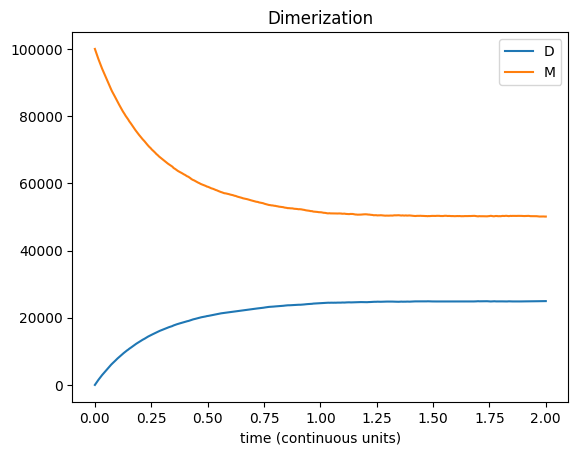

In [2]:
m, d = species('M D')

dimerization = [(2*m | d).k(1).r(1)]

sim = Simulation({m: n}, dimerization, seed=1)
sim.run(2.0, 0.004)
p = sim.history.plot(title='Dimerization')

## Rössler-Willamowski

The Willamowski-Rössler system is a classic chaotic attractor, written as a CRN:

$$\begin{aligned}
X_1 &\xrightarrow{30} 2X_1, & 2X_1 &\xrightarrow{0.5} X_1, \\
X_1 + X_2 &\xrightarrow{1} 2X_2, & X_2 &\xrightarrow{10} \emptyset, \\
X_1 + X_3 &\xrightarrow{1} \emptyset, & X_3 &\xrightarrow{16.5} 2X_3, \\
2X_3 &\xrightarrow{0.5} X_3.
\end{aligned}$$

$X_1$ is autocatalytic and self-limiting, $X_2$ preys on $X_1$ (as the foxes prey on the rabbits), and $X_3$
is a second autocatalytic species that $X_1$ suppresses. The result does not settle into a fixed point or a
clean repeating cycle: it oscillates irregularly, never quite retracing its path.

  0%|          | 0/8.0 [00:00<?, ? time simulated/s]

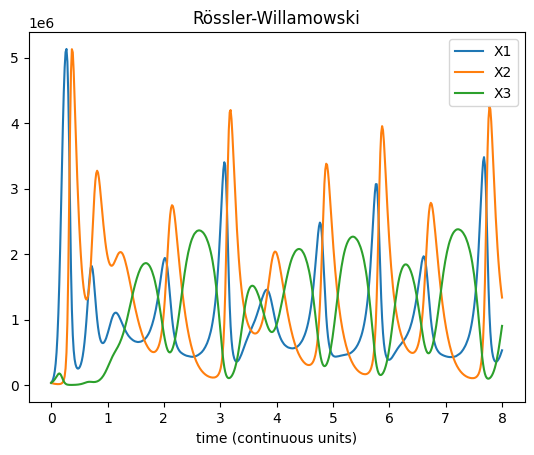

In [3]:
x1, x2, x3 = species('X1 X2 X3')

rossler = [
    (x1 >> 2*x1).k(30),
    (2*x1 >> x1).k(0.5),
    (x2 + x1 >> 2*x2).k(1),
    (x2 >> None).k(10),
    (x1 + x3 >> None).k(1),
    (x3 >> 2*x3).k(16.5),
    (2*x3 >> x3).k(0.5),
]

sim = Simulation({x1: n // 3, x2: n // 3, x3: n // 3}, rossler, seed=1)
sim.run(8.0, 0.016)
p = sim.history.plot(title='Rössler-Willamowski')

## Oregonator

The [Oregonator](https://en.wikipedia.org/wiki/Oregonator) is the standard minimal model of the
Belousov-Zhabotinsky reaction, the textbook example of a chemical oscillator:

$$\begin{aligned}
X_2 &\xrightarrow{0.0871} X_1, & X_1 + X_2 &\xrightarrow{1000} \emptyset, \\
X_1 &\xrightarrow{520} 2X_1 + X_3, & 2X_1 &\xrightarrow{40} \emptyset, \\
X_3 &\xrightarrow{443.324} X_2, & X_3 &\xrightarrow{2.676} \emptyset.
\end{aligned}$$

Two things are worth flagging.

First, the two bimolecular rate constants (1000 and 40) are **reduced from the textbook values** of
$1.6 \times 10^9$ and $4 \times 10^7$. Those are calibrated for concentrations around $10^{-7}$; used
directly at counts of order $n$ they would collapse every species to zero. Scaling them down puts the limit
cycle at counts of order $n$, where we can watch it.

Second, this is the first CRN here that needs `volume=n` passed **explicitly**. The initial condition is
placed directly *on* the limit cycle, so that it oscillates immediately rather than spiralling in — and
those concentrations sum to about $0.54$, not $1$. Since `volume` otherwise defaults to the sum of the
initial counts, we have to say what we mean.

  0%|          | 0/5.0 [00:00<?, ? time simulated/s]

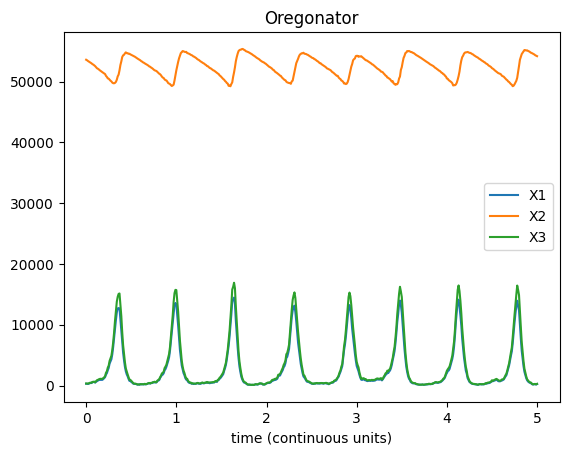

In [4]:
oregonator = [
    (x2 >> x1).k(0.0871),
    (x2 + x1 >> None).k(1000),
    (x1 >> 2*x1 + x3).k(520),
    (2*x1 >> None).k(40),
    (x3 >> x2).k(443.324),
    (x3 >> None).k(2.676),
]

inits = {x1: int(0.0029 * n), x2: int(0.5358 * n), x3: int(0.0034 * n)}

# volume=n, because the initial counts sit on the limit cycle and do not sum to n
sim = Simulation(inits, oregonator, volume=n, seed=1)
sim.run(5.0, 0.01)
p = sim.history.plot(title='Oregonator')

$X_1$ spikes so sharply against $X_2$ that a linear axis flattens it; a `symlog` $y$-axis shows all three
species at once, and the relaxation-oscillator shape — long slow build-up, sudden discharge — becomes
obvious.

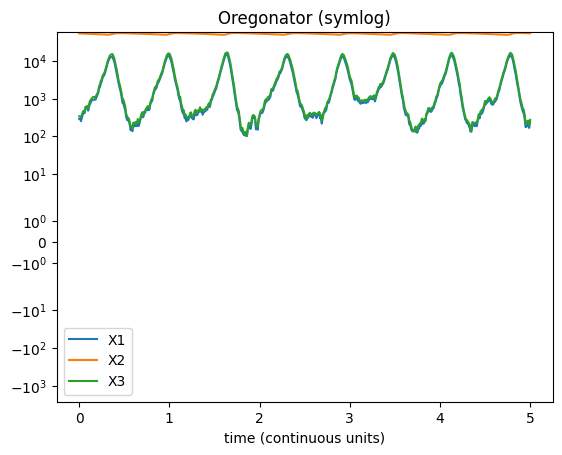

In [5]:
ax = sim.history.plot(title='Oregonator (symlog)')
p = ax.set_yscale('symlog')

## Brusselator

The [Brusselator](https://en.wikipedia.org/wiki/Brusselator) is another classic oscillator, and the only CRN
here with an **order-3** reaction (three reactant molecules):

$$\begin{aligned}
A &\xrightarrow{1} A + X, & 2X + Y &\xrightarrow{1} 3X, \\
B + X &\xrightarrow{1} B + Y, & X &\xrightarrow{1} \emptyset.
\end{aligned}$$

$A$ and $B$ are catalytic *fuel*: each appears on both sides of its reaction, so their counts never change
and the reservoir never depletes. With $[A] = 1$ and $[B] = 3$ held fixed, the steady state is unstable
(because $b > 1 + a^2$) and the system settles onto a sustained limit cycle. As with the Oregonator, the
initial counts do not sum to $n$, so `volume=n` is given explicitly.

  0%|          | 0/20.0 [00:00<?, ? time simulated/s]

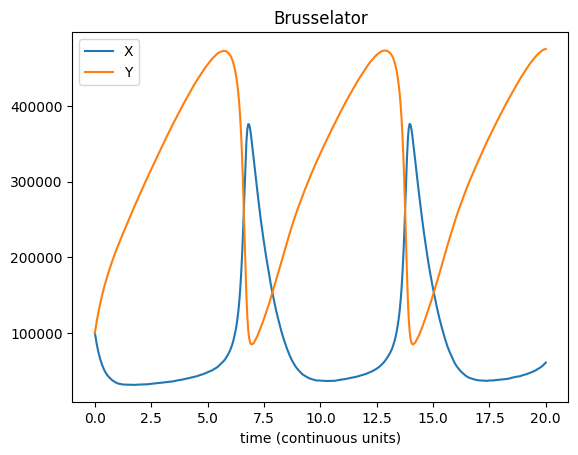

In [6]:
a, b, x, y = species('A B X Y')

brusselator = [
    (a >> a + x).k(1),
    (2*x + y >> 3*x).k(1),
    (b + x >> b + y).k(1),
    (x >> None).k(1),
]

sim = Simulation({a: n, b: 3*n, x: n, y: n}, brusselator, volume=n, seed=1)
sim.run(20.0, 0.04)

# A and B are constant fuel, so only X and Y are interesting to plot
p = sim.history[['X', 'Y']].plot(title='Brusselator')

## A note on speed

batss is not equally fast on every CRN. Of the five CRNs across the README and this notebook, dimerization,
Lotka-Volterra and Rössler-Willamowski all show a large speedup over the Gillespie algorithm that grows with
the population size. The **Oregonator** and the **Brusselator** do not: batss is only modestly faster than
Gillespie on the Oregonator until the population gets very large, and on the Brusselator it merely matches
it.

For technical reasons, on these two CRNs batss ends up simulating a large number of *passive* reactions —
reactions that are sampled but do not actually advance the CRN — and that overhead eats the gains from
batching. See [the paper](https://arxiv.org/abs/2508.04079) for the details.

You do not need to know any of this to use batss; it is simply why these two run slower than you might
expect. The [benchmark notebook](../benchmark/benchmark.ipynb) has the measurements.